# Отчёт NL2SQL: режим EA

Ноутбук содержит анализ режима `ea` для наборов Spider и BIRD. В этом режиме оценивается качество первого выбранного SQL-запроса, поэтому основной метрикой выступает `Execution Accuracy`. Результаты режима многократной генерации рассматриваются отдельно.


## 1. Подготовка и источники данных

В разделе фиксируются пути к готовым результатам экспериментов, загружаются JSONL-файлы с предсказаниями и агрегированные метрики. Инференс повторно не запускается: ноутбук работает только с уже сохранёнными артефактами.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent):
    if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'nl2sql' / 'notebooks') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'nl2sql' / 'notebooks'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from analysis_utils import (
    DATA_DIR,
    compute_sample_outcomes,
    ensure_expert_template,
    first_non_null,
    get_figures_dir,
    get_results_dir,
    load_records,
    load_summary_metrics,
    reset_analysis_caches,
)

RUN_LABEL = 'ea'
FIGURES_DIR = get_figures_dir(RUN_LABEL)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
print(f'Using results directory: {get_results_dir()}')
print(f'Run label: {RUN_LABEL}')
print(f'Data directory: {DATA_DIR}')
print(f'Figures directory: {FIGURES_DIR}')


Using results directory: /home/count/code/vkr/results/nl2sql
Run label: ea
Data directory: /home/count/code/vkr/data/nl2sql
Figures directory: /home/count/code/vkr/results/nl2sql/figures/ea


In [2]:
reset_analysis_caches()
samples_df, generations_df = load_records(RUN_LABEL)
summary_df = load_summary_metrics(RUN_LABEL).copy()
outcomes_df = compute_sample_outcomes(RUN_LABEL).copy()
if 'model_display_name' not in summary_df.columns:
    summary_df['model_display_name'] = summary_df['model_name']
if 'model_display_name' not in outcomes_df.columns:
    outcomes_df['model_display_name'] = outcomes_df['model_name']

expert_path = ensure_expert_template(RUN_LABEL)

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]


print('samples:', samples_df.shape)
print('generations:', generations_df.shape)
print('summary:', summary_df.shape)
print('outcomes:', outcomes_df.shape)
print('expert template/file:', expert_path)

pass_metric_cols = sorted(
    [col for col in summary_df.columns if col.startswith('pass@') and col.split('@', 1)[1].isdigit()],
    key=lambda col: int(col.split('@', 1)[1]),
)
summary_preview_cols = ['model_display_name', 'benchmark', 'run_label', 'n_samples', 'execution_accuracy', *pass_metric_cols]
summary_df[summary_df['model_display_name'].isin(MAIN_REPORT_MODELS)][summary_preview_cols].round(4)


samples: (15408, 17)
generations: (15408, 17)
summary: (12, 55)
outcomes: (15408, 30)
expert template/file: /home/count/code/vkr/results/nl2sql/metrics/ea/expert_scores.csv


,model_display_name,benchmark,run_label,n_samples,execution_accuracy,pass@1,pass@3,pass@5
0,Arctic-Text2SQL-R1-7B,bird,ea,1534,0.5385,0.5385,0.5385,0.5385
1,Arctic-Text2SQL-R1-7B,spider,ea,1034,0.7718,0.7718,0.7718,0.7718
2,ChatGPT 5.2,bird,ea,1534,0.3657,0.3657,0.3657,0.3657
3,ChatGPT 5.2,spider,ea,1034,0.7427,0.7427,0.7427,0.7427
6,DeepSeek V3.2,bird,ea,1534,0.3227,0.3227,0.3227,0.3227
7,DeepSeek V3.2,spider,ea,1034,0.7369,0.7369,0.7369,0.7369
8,Defog-Llama3-SQLCoder-8B q4_0,bird,ea,1534,0.2634,0.2634,0.2634,0.2634
9,Defog-Llama3-SQLCoder-8B q4_0,spider,ea,1034,0.5629,0.5629,0.5629,0.5629
10,Hrida-T2SQL q8_0,bird,ea,1534,0.1551,0.1551,0.1551,0.1551
11,Hrida-T2SQL q8_0,spider,ea,1034,0.4913,0.4913,0.4913,0.4913


## 2. Обзор набора данных

Перед сравнением моделей проверяются базовые характеристики текущего среза результатов: число задач по наборам данных, длина естественно-языковых вопросов, длина эталонных SQL-запросов и доступные уровни сложности.


,n_samples,mean_question_len,median_question_len,mean_gold_sql_len,median_gold_sql_len
Набор данных,,,,,
BIRD,1534,82.76,79.0,161.47,151.5
Spider,1034,68.05,66.0,106.69,89.0


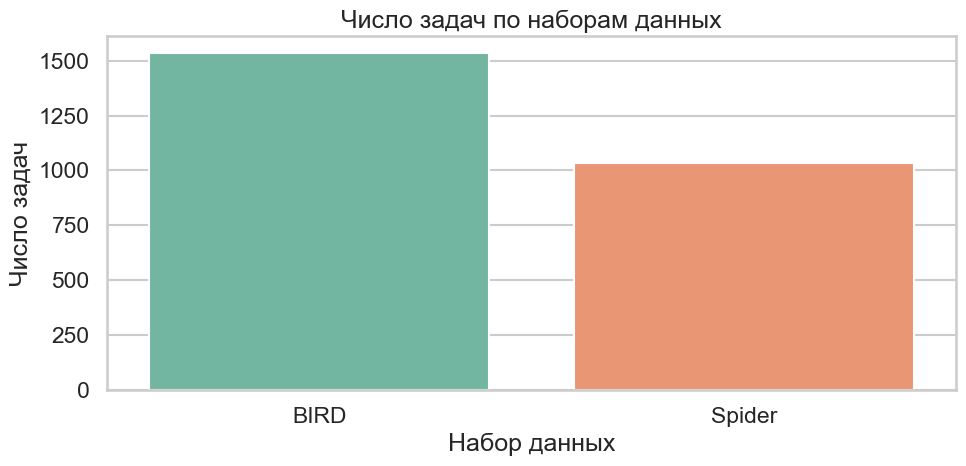

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/dataset_samples_ru.png


/tmp/ipykernel_22053/900199362.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


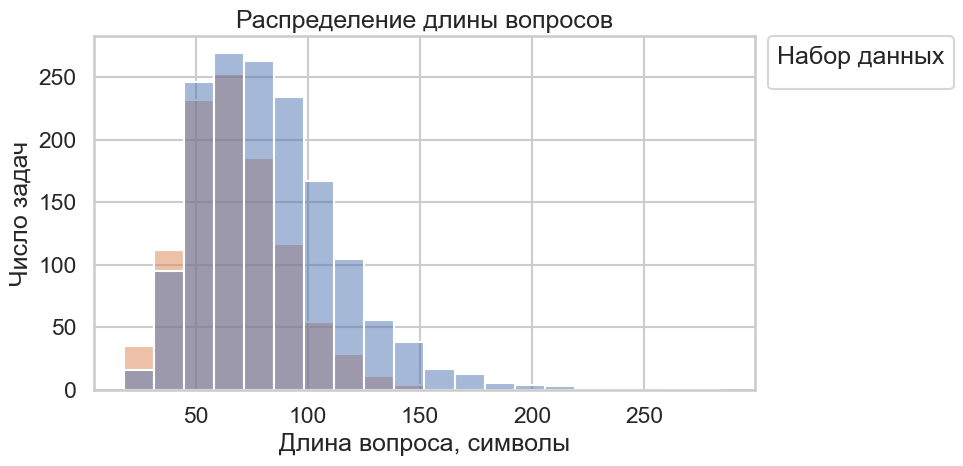

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/dataset_question_length_ru.png


/tmp/ipykernel_22053/900199362.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


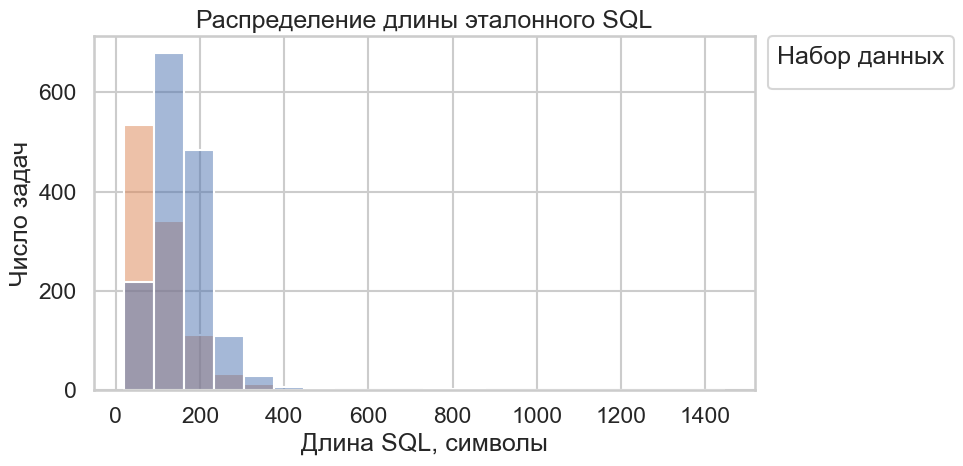

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/dataset_gold_sql_length_ru.png


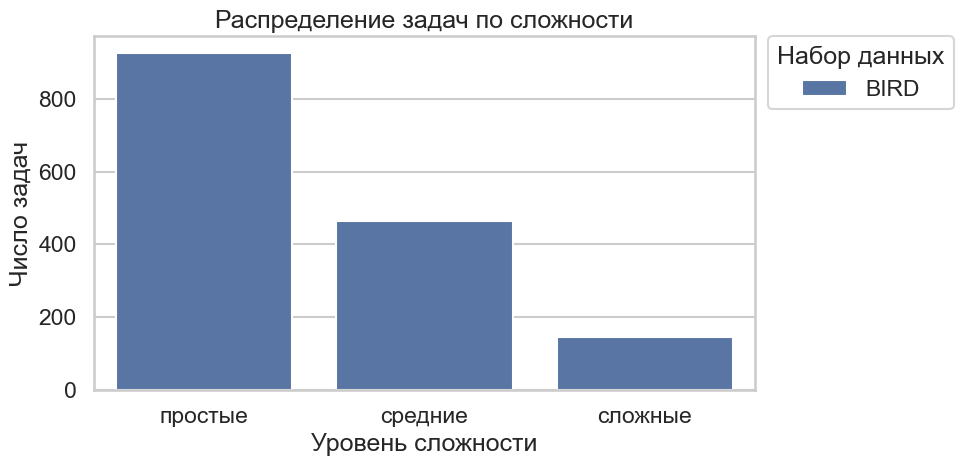

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/dataset_difficulty_ru.png
Созданные обзорные графики:
/home/count/code/vkr/results/nl2sql/figures/ea/dataset_samples_ru.png
/home/count/code/vkr/results/nl2sql/figures/ea/dataset_question_length_ru.png
/home/count/code/vkr/results/nl2sql/figures/ea/dataset_gold_sql_length_ru.png
/home/count/code/vkr/results/nl2sql/figures/ea/dataset_difficulty_ru.png


In [3]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

if samples_df.empty:
    raise ValueError('Нет raw-данных для отчета.')

unique_samples = (
    samples_df.sort_values(['benchmark', 'sample_id'])
    .drop_duplicates(subset=['benchmark', 'sample_id'])
    .copy()
)
unique_samples['benchmark_ru'] = unique_samples['benchmark'].map(BENCHMARK_LABELS).fillna(unique_samples['benchmark'])
unique_samples['difficulty_ru'] = unique_samples['difficulty'].map(DIFFICULTY_LABELS).fillna(unique_samples['difficulty'])

overview = unique_samples.groupby('benchmark_ru').agg(
    n_samples=('sample_id', 'nunique'),
    mean_question_len=('question_len', 'mean'),
    median_question_len=('question_len', 'median'),
    mean_gold_sql_len=('gold_sql_len', 'mean'),
    median_gold_sql_len=('gold_sql_len', 'median'),
).rename_axis('Набор данных')

display(overview.round(2))
created_figures = []

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=unique_samples, x='benchmark_ru', hue='benchmark_ru', palette='Set2', legend=False, ax=ax)
ax.set_title('Число задач по наборам данных')
ax.set_xlabel('Набор данных')
ax.set_ylabel('Число задач')
path = FIGURES_DIR / 'dataset_samples_ru.png'
_save_current(fig, path)
created_figures.append(path)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=unique_samples, x='question_len', hue='benchmark_ru', bins=20, multiple='layer', ax=ax)
ax.set_title('Распределение длины вопросов')
ax.set_xlabel('Длина вопроса, символы')
ax.set_ylabel('Число задач')
_legend_outside(ax, 'Набор данных')
path = FIGURES_DIR / 'dataset_question_length_ru.png'
_save_current(fig, path)
created_figures.append(path)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=unique_samples, x='gold_sql_len', hue='benchmark_ru', bins=20, multiple='layer', ax=ax)
ax.set_title('Распределение длины эталонного SQL')
ax.set_xlabel('Длина SQL, символы')
ax.set_ylabel('Число задач')
_legend_outside(ax, 'Набор данных')
path = FIGURES_DIR / 'dataset_gold_sql_length_ru.png'
_save_current(fig, path)
created_figures.append(path)

if unique_samples['difficulty'].notna().any():
    difficulty_df = unique_samples.dropna(subset=['difficulty_ru']).copy()
    order = [label for label in ['простые', 'средние', 'сложные'] if label in set(difficulty_df['difficulty_ru'])]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=difficulty_df, x='difficulty_ru', hue='benchmark_ru', order=order or None, ax=ax)
    ax.set_title('Распределение задач по сложности')
    ax.set_xlabel('Уровень сложности')
    ax.set_ylabel('Число задач')
    _legend_outside(ax, 'Набор данных')
    path = FIGURES_DIR / 'dataset_difficulty_ru.png'
    _save_current(fig, path)
    created_figures.append(path)
else:
    print('Сложность задач не указана: график распределения по сложности не создан.')

print('Созданные обзорные графики:')
for path in created_figures:
    print(path)


## 3. Основные результаты

В этом разделе рассматривается только `Execution Accuracy`: доля задач, для которых первый выбранный SQL-запрос даёт корректный результат при выполнении. Показатель сравнивается по моделям и наборам Spider/BIRD. `Pass@K` вынесен в отдельный отчёт, поскольку описывает другой сценарий — несколько независимых попыток генерации.


,model_display_name,benchmark,execution_accuracy,pass@1,pass@3,pass@5
0,Arctic-Text2SQL-R1-7B,bird,0.5385,0.5385,0.5385,0.5385
1,Arctic-Text2SQL-R1-7B,spider,0.7718,0.7718,0.7718,0.7718
2,ChatGPT 5.2,bird,0.3657,0.3657,0.3657,0.3657
3,ChatGPT 5.2,spider,0.7427,0.7427,0.7427,0.7427
6,DeepSeek V3.2,bird,0.3227,0.3227,0.3227,0.3227
7,DeepSeek V3.2,spider,0.7369,0.7369,0.7369,0.7369
8,Defog-Llama3-SQLCoder-8B q4_0,bird,0.2634,0.2634,0.2634,0.2634
9,Defog-Llama3-SQLCoder-8B q4_0,spider,0.5629,0.5629,0.5629,0.5629
10,Hrida-T2SQL q8_0,bird,0.1551,0.1551,0.1551,0.1551
11,Hrida-T2SQL q8_0,spider,0.4913,0.4913,0.4913,0.4913


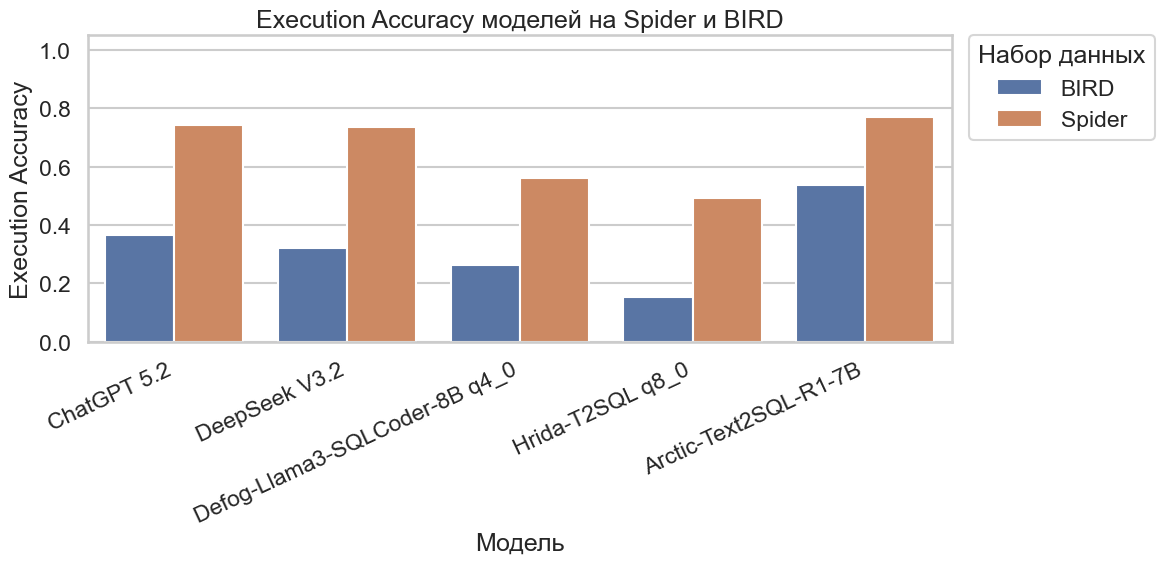

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/ea_by_benchmark_ru.png


In [4]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]

main_metrics = summary_df[summary_df['model_display_name'].isin(MAIN_REPORT_MODELS)][
    ['model_display_name', 'benchmark', 'execution_accuracy', *pass_metric_cols]
].copy()
display(main_metrics.round(4))

ea_plot_df = summary_df[['model_display_name', 'benchmark', 'execution_accuracy']].copy()
ea_plot_df = ea_plot_df[ea_plot_df['model_display_name'].isin(MAIN_REPORT_MODELS)].copy()
ea_plot_df['benchmark_ru'] = ea_plot_df['benchmark'].map(BENCHMARK_LABELS).fillna(ea_plot_df['benchmark'])
ea_plot_df['model_display_name'] = pd.Categorical(
    ea_plot_df['model_display_name'],
    categories=MAIN_REPORT_MODELS,
    ordered=True,
)
ea_plot_df = ea_plot_df.sort_values(['model_display_name', 'benchmark_ru'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=ea_plot_df,
    x='model_display_name',
    y='execution_accuracy',
    hue='benchmark_ru',
    ax=ax,
)
ax.set_title('Execution Accuracy моделей на Spider и BIRD')
ax.set_xlabel('Модель')
ax.set_ylabel('Execution Accuracy')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=25)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.legend(title='Набор данных', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
fig.tight_layout()
figure_path = FIGURES_DIR / 'ea_by_benchmark_ru.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {figure_path}')


График следует читать как сравнение качества одного ответа. Для каждой модели показано, как её результат меняется между Spider и BIRD. Такое разделение важно: усреднение двух наборов данных скрывало бы различие сложности, тогда как именно падение качества на BIRD показывает границы применимости моделей.


## 4. Вычислительный профиль

В этом разделе качество сопоставляется с вычислительными характеристиками: временем инференса, числом токенов, оценочной стоимостью и интегральным показателем эффективности. Эти величины не заменяют `Execution Accuracy`, а описывают цену достижения наблюдаемого качества.


,model_display_name,benchmark,Tinf,Tok,Cost,Eff_normalized,benchmark_ru
2,ChatGPT 5.2,bird,2374.4675,1021.2171,0.0019,0.6127,BIRD
3,ChatGPT 5.2,spider,1895.3430,479.2563,0.0009,0.2625,Spider
6,DeepSeek V3.2,bird,3494.5106,1051.5183,0.0003,0.4020,BIRD
7,DeepSeek V3.2,spider,2965.6751,514.9168,0.0002,0.1871,Spider
8,Defog-Llama3-SQLCoder-8B q4_0,bird,733.3158,974.1232,0.0000,0.1753,BIRD
9,Defog-Llama3-SQLCoder-8B q4_0,spider,531.0612,426.9159,0.0000,0.0025,Spider
10,Hrida-T2SQL q8_0,bird,1081.1594,1440.4817,0.0000,0.3322,BIRD
11,Hrida-T2SQL q8_0,spider,485.6148,668.4507,0.0000,0.0715,Spider
0,Arctic-Text2SQL-R1-7B,bird,6038.1180,1335.3716,0.0000,0.5689,BIRD
1,Arctic-Text2SQL-R1-7B,spider,4854.2380,734.6422,0.0000,0.3271,Spider


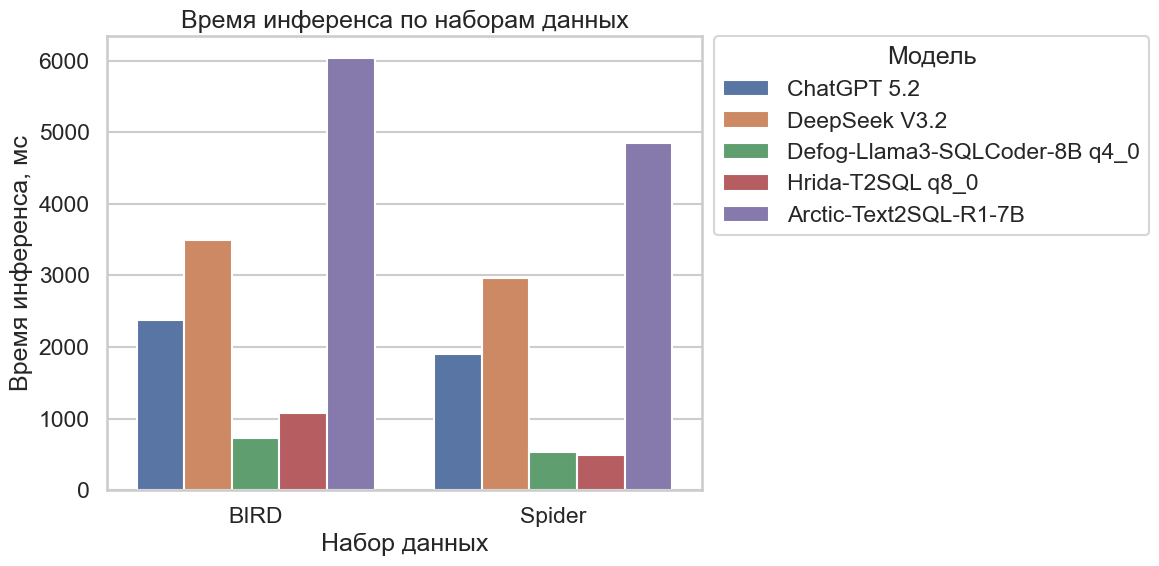

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/eff_latency_ru.png


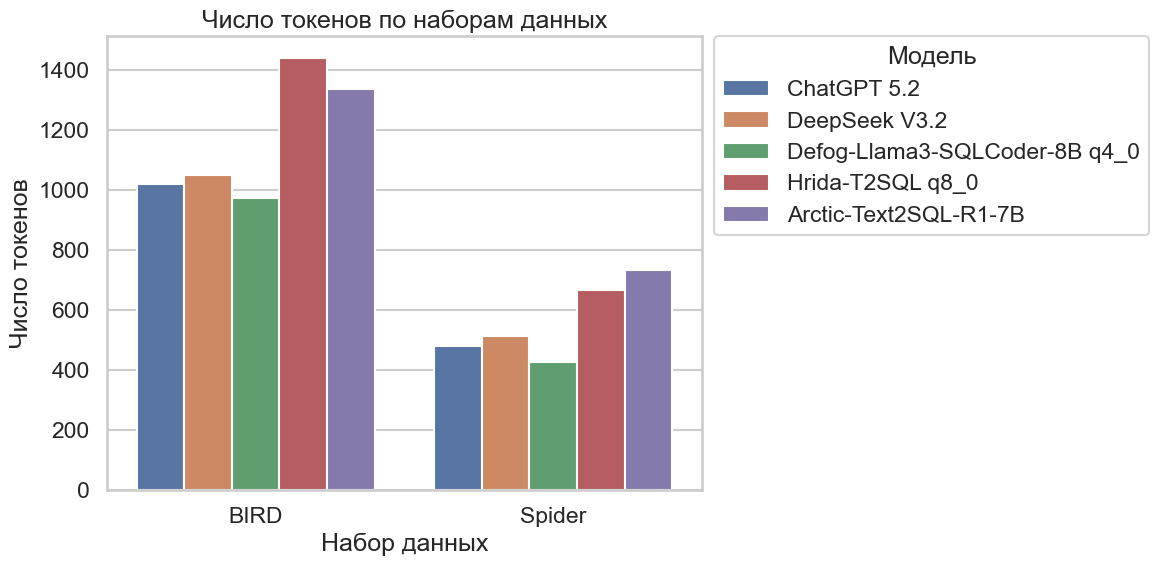

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/eff_tokens_ru.png


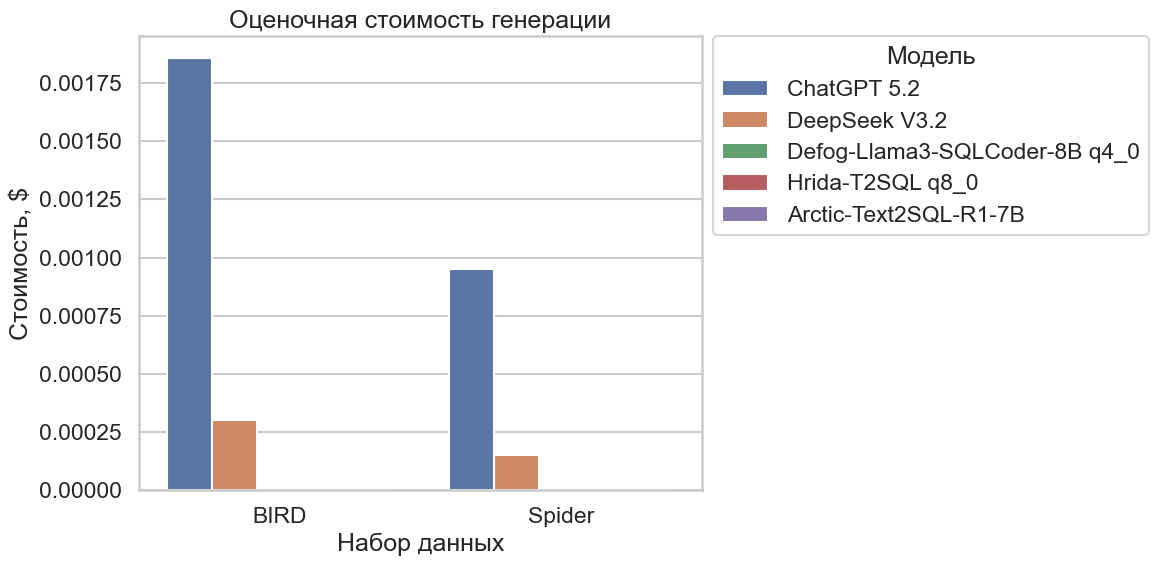

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/eff_cost_ru.png


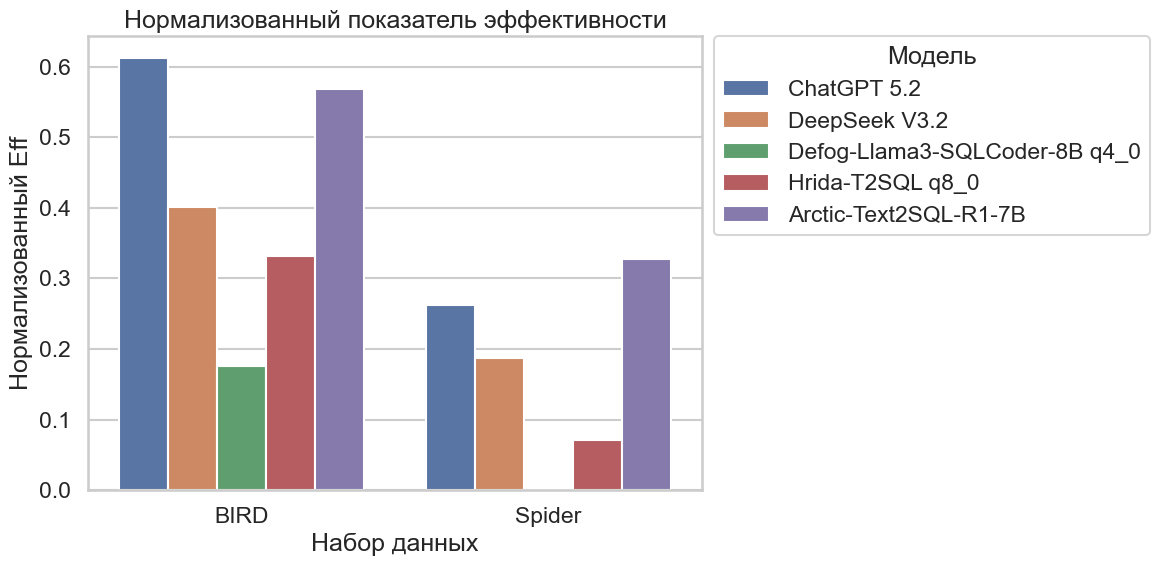

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/eff_normalized_ru.png
Созданные графики вычислительного профиля:
/home/count/code/vkr/results/nl2sql/figures/ea/eff_latency_ru.png
/home/count/code/vkr/results/nl2sql/figures/ea/eff_tokens_ru.png
/home/count/code/vkr/results/nl2sql/figures/ea/eff_cost_ru.png
/home/count/code/vkr/results/nl2sql/figures/ea/eff_normalized_ru.png


In [5]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

eff_df = summary_df[summary_df['model_display_name'].isin(MAIN_REPORT_MODELS)][
    ['model_display_name', 'benchmark', 'Tinf', 'Tok', 'Cost', 'Eff_normalized']
].copy()
eff_df['model_display_name'] = pd.Categorical(eff_df['model_display_name'], categories=MAIN_REPORT_MODELS, ordered=True)
eff_df['benchmark_ru'] = eff_df['benchmark'].map(BENCHMARK_LABELS).fillna(eff_df['benchmark'])
eff_df = eff_df.sort_values(['model_display_name', 'benchmark_ru'])
display(eff_df.round(4))

metric_specs = [
    ('Tinf', 'Время инференса по наборам данных', 'Время инференса, мс', 'eff_latency_ru.png'),
    ('Tok', 'Число токенов по наборам данных', 'Число токенов', 'eff_tokens_ru.png'),
    ('Cost', 'Оценочная стоимость генерации', 'Стоимость, $', 'eff_cost_ru.png'),
]
created_figures = []
for column, title, ylabel, filename in metric_specs:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=eff_df, x='benchmark_ru', y=column, hue='model_display_name', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Набор данных')
    ax.set_ylabel(ylabel)
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / filename
    _save_current(fig, path)
    created_figures.append(path)

if summary_df['Eff_normalized'].notna().any():
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=eff_df, x='benchmark_ru', y='Eff_normalized', hue='model_display_name', ax=ax)
    ax.set_title('Нормализованный показатель эффективности')
    ax.set_xlabel('Набор данных')
    ax.set_ylabel('Нормализованный Eff')
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / 'eff_normalized_ru.png'
    _save_current(fig, path)
    created_figures.append(path)

print('Созданные графики вычислительного профиля:')
for path in created_figures:
    print(path)


## 5. Парные сравнения моделей

Парные сравнения рассчитываются на уровне одних и тех же задач. Такой срез показывает не только среднюю разницу в `Execution Accuracy`, но и устойчивость различий между моделями на общем наборе наблюдений.


,Бенчмарк,Набор данных,Модель A,Модель B,Сравнение моделей,EA модели A,EA модели B,ΔEA,Нижняя граница 95% ДИ,Верхняя граница 95% ДИ,Корректна только модель A,Корректна только модель B
0,bird,BIRD,Arctic-Text2SQL-R1-7B,ChatGPT 5.2,Arctic-Text2SQL-R1-7B против ChatGPT 5.2,0.5385,0.3657,0.1728,0.1454,0.2001,379,114
1,bird,BIRD,Arctic-Text2SQL-R1-7B,DeepSeek V3.2,Arctic-Text2SQL-R1-7B против DeepSeek V3.2,0.5385,0.3227,0.2158,0.1903,0.2425,415,84
2,bird,BIRD,Arctic-Text2SQL-R1-7B,Defog-Llama3-SQLCoder-8B q4_0,Arctic-Text2SQL-R1-7B против Defog-Llama3-SQLC...,0.5385,0.2634,0.2751,0.2464,0.3044,508,86
3,bird,BIRD,Arctic-Text2SQL-R1-7B,Hrida-T2SQL q8_0,Arctic-Text2SQL-R1-7B против Hrida-T2SQL q8_0,0.5385,0.1551,0.3833,0.3540,0.4100,624,36
4,bird,BIRD,ChatGPT 5.2,DeepSeek V3.2,ChatGPT 5.2 против DeepSeek V3.2,0.3657,0.3227,0.0430,0.0235,0.0619,147,81
5,bird,BIRD,ChatGPT 5.2,Defog-Llama3-SQLCoder-8B q4_0,ChatGPT 5.2 против Defog-Llama3-SQLCoder-8B q4_0,0.3657,0.2634,0.1023,0.0763,0.1323,328,171
6,bird,BIRD,ChatGPT 5.2,Hrida-T2SQL q8_0,ChatGPT 5.2 против Hrida-T2SQL q8_0,0.3657,0.1551,0.2106,0.1838,0.2392,423,100
7,bird,BIRD,DeepSeek V3.2,Defog-Llama3-SQLCoder-8B q4_0,DeepSeek V3.2 против Defog-Llama3-SQLCoder-8B ...,0.3227,0.2634,0.0593,0.0313,0.0893,291,200
8,bird,BIRD,DeepSeek V3.2,Hrida-T2SQL q8_0,DeepSeek V3.2 против Hrida-T2SQL q8_0,0.3227,0.1551,0.1675,0.1415,0.1943,365,108
9,bird,BIRD,Defog-Llama3-SQLCoder-8B q4_0,Hrida-T2SQL q8_0,Defog-Llama3-SQLCoder-8B q4_0 против Hrida-T2S...,0.2634,0.1551,0.1082,0.0867,0.1284,243,77


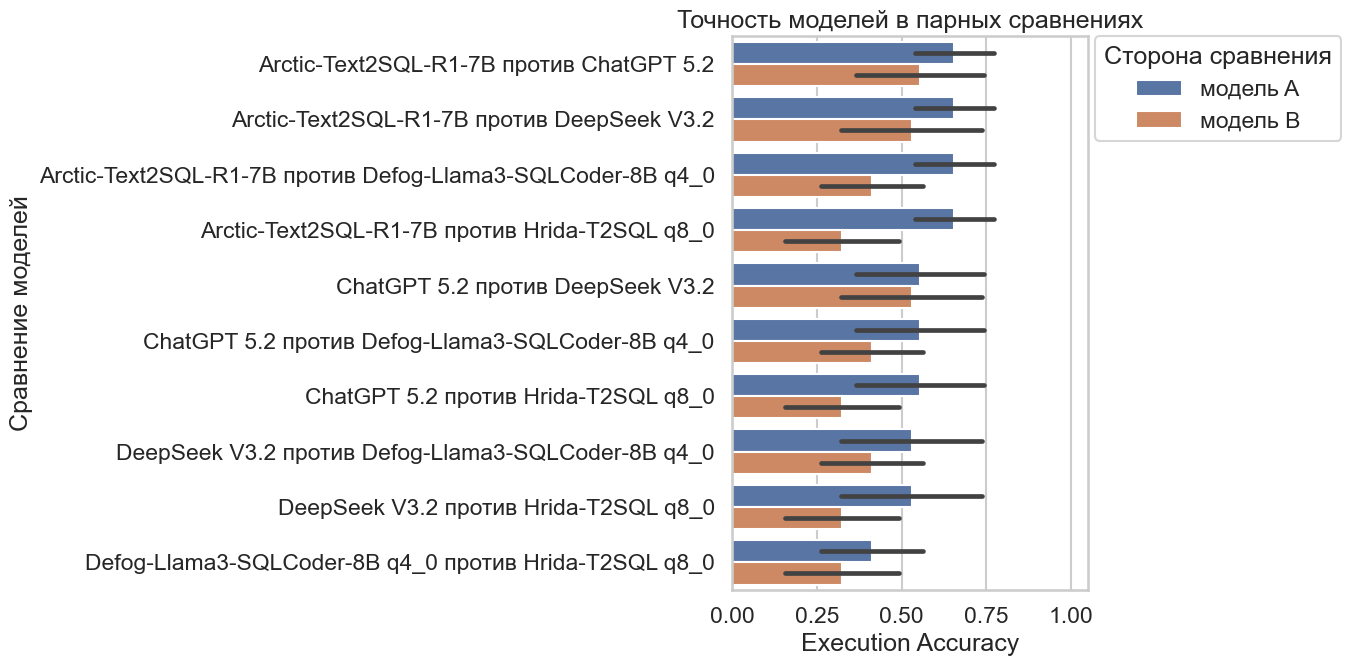

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/pairwise_accuracy_ru.png


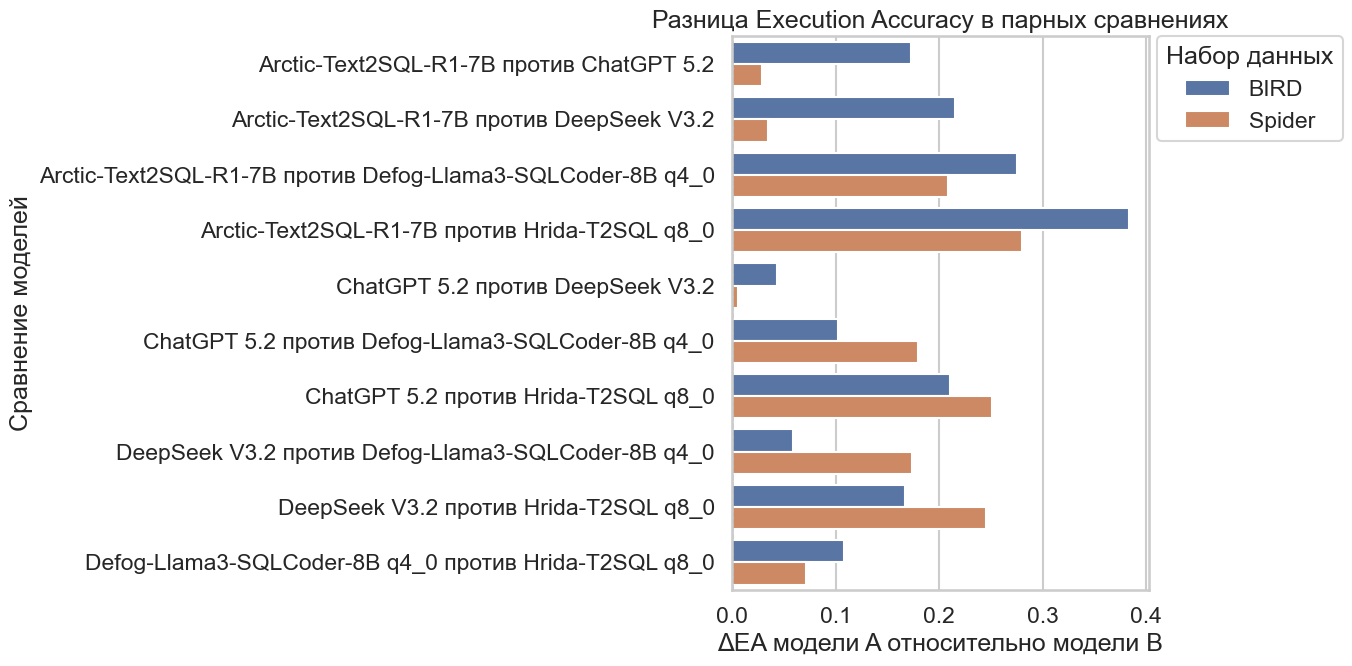

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/pairwise_delta_ru.png


In [6]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]

from itertools import combinations

rows = []
pairwise_outcomes_df = outcomes_df[outcomes_df['model_display_name'].isin(MAIN_REPORT_MODELS)].copy()

for benchmark, group in pairwise_outcomes_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_display_name', values='first_hit', aggfunc='first')
    model_names = list(pivot.columns)
    if len(model_names) < 2:
        continue

    for left, right in combinations(model_names, 2):
        left_vals = pivot[left].fillna(False).astype(bool)
        right_vals = pivot[right].fillna(False).astype(bool)
        diff = float(left_vals.mean() - right_vals.mean())

        diffs = []
        if len(pivot) > 1:
            pair_df = pd.DataFrame({'left': left_vals, 'right': right_vals})
            for _ in range(1000):
                sample = pair_df.sample(n=len(pair_df), replace=True)
                diffs.append(float(sample['left'].mean() - sample['right'].mean()))
            ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
        else:
            ci_low = ci_high = diff

        rows.append({
            'benchmark': benchmark,
            'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark),
            'left_model': left,
            'right_model': right,
            'pair': f'{left} vs {right}',
            'left_accuracy': float(left_vals.mean()),
            'right_accuracy': float(right_vals.mean()),
            'accuracy_diff': diff,
            'ci_low': float(ci_low),
            'ci_high': float(ci_high),
            'left_only_correct': int((left_vals & ~right_vals).sum()),
            'right_only_correct': int((~left_vals & right_vals).sum()),
        })

hyp_df = pd.DataFrame(rows)
hyp_display_df = hyp_df.copy()
if not hyp_display_df.empty:
    hyp_display_df['pair'] = hyp_display_df['pair'].str.replace(' vs ', ' против ', regex=False)
    hyp_display_df = hyp_display_df.rename(columns={
        'benchmark': 'Бенчмарк',
        'benchmark_ru': 'Набор данных',
        'left_model': 'Модель A',
        'right_model': 'Модель B',
        'pair': 'Сравнение моделей',
        'left_accuracy': 'EA модели A',
        'right_accuracy': 'EA модели B',
        'accuracy_diff': 'ΔEA',
        'ci_low': 'Нижняя граница 95% ДИ',
        'ci_high': 'Верхняя граница 95% ДИ',
        'left_only_correct': 'Корректна только модель A',
        'right_only_correct': 'Корректна только модель B',
    })
display(hyp_display_df.round(4))

if not hyp_df.empty:
    accuracy_plot_df = hyp_df.melt(
        id_vars=['benchmark_ru', 'pair'],
        value_vars=['left_accuracy', 'right_accuracy'],
        var_name='side',
        value_name='accuracy',
    )
    accuracy_plot_df['side_ru'] = accuracy_plot_df['side'].map(SIDE_LABELS).fillna(accuracy_plot_df['side'])
    accuracy_plot_df['comparison_ru'] = accuracy_plot_df['pair'].str.replace(' vs ', ' против ', regex=False)

    fig, ax = plt.subplots(figsize=(14, max(7, 0.35 * len(accuracy_plot_df['comparison_ru'].unique()))))
    sns.barplot(data=accuracy_plot_df, y='comparison_ru', x='accuracy', hue='side_ru', ax=ax)
    ax.set_title('Точность моделей в парных сравнениях')
    ax.set_xlabel('Execution Accuracy')
    ax.set_ylabel('Сравнение моделей')
    ax.set_xlim(0, 1.05)
    _legend_outside(ax, 'Сторона сравнения')
    path = FIGURES_DIR / 'pairwise_accuracy_ru.png'
    _save_current(fig, path)

    delta_df = hyp_df.copy()
    delta_df['comparison_ru'] = delta_df['pair'].str.replace(' vs ', ' против ', regex=False)
    fig, ax = plt.subplots(figsize=(14, max(7, 0.28 * len(delta_df))))
    sns.barplot(data=delta_df, y='comparison_ru', x='accuracy_diff', hue='benchmark_ru', ax=ax)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Разница Execution Accuracy в парных сравнениях')
    ax.set_xlabel('ΔEA модели A относительно модели B')
    ax.set_ylabel('Сравнение моделей')
    _legend_outside(ax, 'Набор данных')
    path = FIGURES_DIR / 'pairwise_delta_ru.png'
    _save_current(fig, path)
else:
    print('Недостаточно моделей для построения парных сравнений.')


## 6. Анализ ошибок

Раздел показывает, чем заканчиваются неуспешные генерации: пустым SQL, ошибкой выполнения или исполнимым запросом с неверным результатом. Дополнительно рассматривается пересечение правильных ответов между моделями и примеры ошибок на уровне отдельных задач.


,sample_id,benchmark,model_display_name,error_category,first_pred_error
0,bird_0,bird,Arctic-Text2SQL-R1-7B,correct,NaN
1,bird_1,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN
2,bird_2,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN
3,bird_3,bird,Arctic-Text2SQL-R1-7B,correct,NaN
4,bird_4,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN


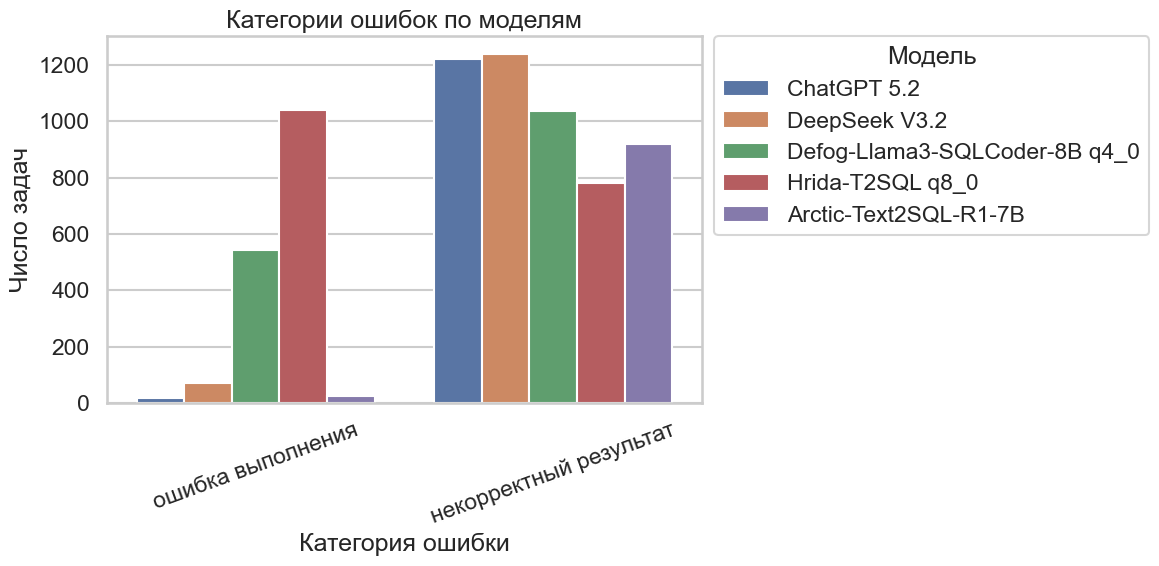

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/error_categories_ru.png


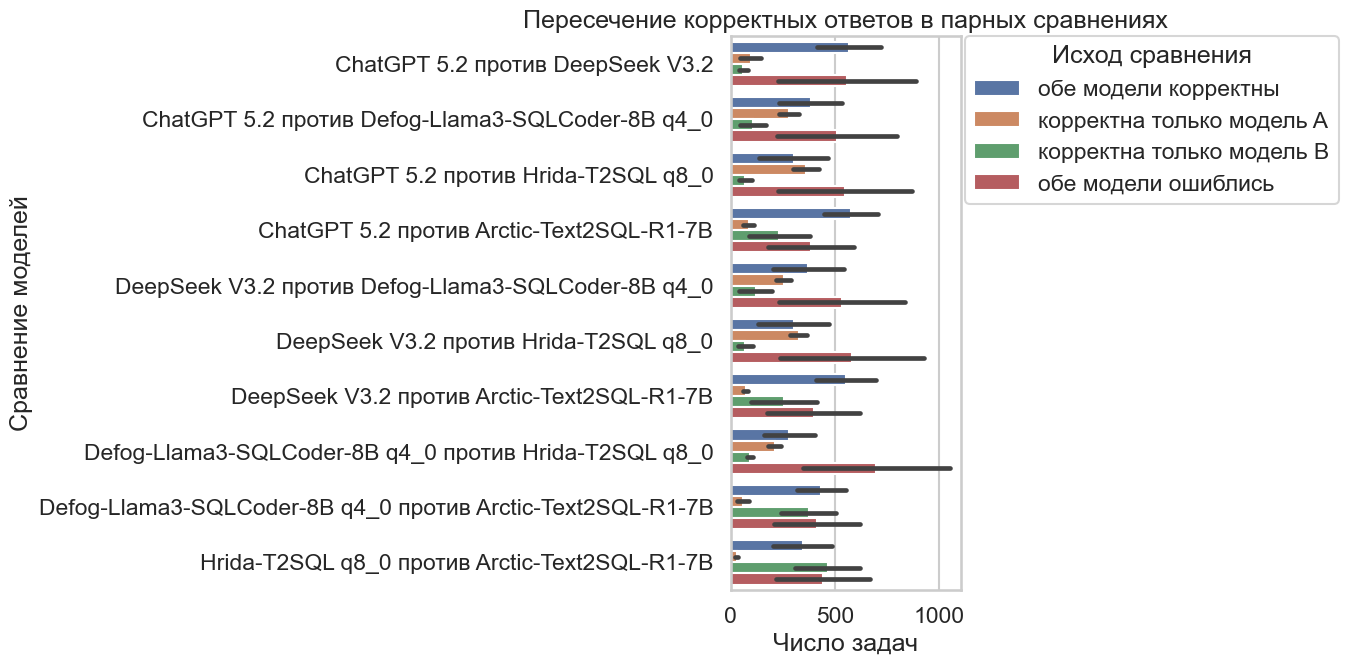

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/correctness_overlap_ru.png


,benchmark,model_display_name,sample_id,question,gold_sql,first_pred_sql,error_category,first_pred_error
1,bird,Arctic-Text2SQL-R1-7B,bird_1,Please list the lowest three eligible free rat...,SELECT `Free Meal Count (Ages 5-17)` / `Enroll...,"SELECT \n `County Name`, \n `District Na...",wrong_result,NaN
2,bird,Arctic-Text2SQL-R1-7B,bird_2,Please list the zip code of all the charter sc...,SELECT T2.Zip FROM frpm AS T1 INNER JOIN schoo...,SELECT DISTINCT s.Zip\nFROM schools AS s\nINNE...,wrong_result,NaN
4,bird,Arctic-Text2SQL-R1-7B,bird_4,Please list the phone numbers of the direct ch...,SELECT T2.Phone FROM frpm AS T1 INNER JOIN sch...,SELECT DISTINCT s.Phone\nFROM schools AS s\nIN...,wrong_result,NaN
6,bird,Arctic-Text2SQL-R1-7B,bird_6,Among the schools with the SAT test takers of ...,SELECT T2.School FROM satscores AS T1 INNER JO...,SELECT DISTINCT s.School\nFROM schools AS s\nI...,wrong_result,NaN
9,bird,Arctic-Text2SQL-R1-7B,bird_9,Among the schools with the average score in Ma...,SELECT COUNT(T2.`School Code`) FROM satscores ...,SELECT COUNT(*) AS DirectlyCharterFundedCount\...,wrong_result,NaN
10,bird,Arctic-Text2SQL-R1-7B,bird_10,For the school with the highest average score ...,SELECT T2.`FRPM Count (Ages 5-17)` FROM satsco...,SELECT \n f.`FRPM Count (Ages 5-17)`\nFROM ...,wrong_result,NaN
15,bird,Arctic-Text2SQL-R1-7B,bird_15,Which active district has the highest average ...,SELECT T1.District FROM schools AS T1 INNER JO...,"SELECT \n T2.dname AS DistrictName,\n AV...",wrong_result,NaN
16,bird,Arctic-Text2SQL-R1-7B,bird_16,How many schools in merged Alameda have number...,SELECT COUNT(T1.CDSCode) FROM schools AS T1 IN...,SELECT \n COUNT(*) AS TotalSchools\nFROM \n...,wrong_result,NaN
17,bird,Arctic-Text2SQL-R1-7B,bird_17,Rank schools by their average score in Writing...,"SELECT CharterNum, AvgScrWrite, RANK() OVER (O...","SELECT \n s.CharterNum,\n ss.AvgScrWrite...",wrong_result,NaN
18,bird,Arctic-Text2SQL-R1-7B,bird_18,How many schools in Fresno (directly funded) h...,SELECT COUNT(T1.CDSCode) FROM frpm AS T1 INNER...,SELECT \n COUNT(*) AS Total_Schools\nFROM \...,wrong_result,NaN


In [7]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

from itertools import combinations

def categorize(row):
    if row['first_hit']:
        return 'correct'
    if row['empty_sql']:
        return 'empty_sql'
    if not row['first_pred_success']:
        return 'execution_error'
    return 'wrong_result'

error_df = outcomes_df[outcomes_df['model_display_name'].isin(MAIN_REPORT_MODELS)].copy()
error_df['model_display_name'] = pd.Categorical(error_df['model_display_name'], categories=MAIN_REPORT_MODELS, ordered=True)
error_df['error_category'] = error_df.apply(categorize, axis=1)
error_df['error_category_ru'] = error_df['error_category'].map(ERROR_LABELS).fillna(error_df['error_category'])
error_df['benchmark_ru'] = error_df['benchmark'].map(BENCHMARK_LABELS).fillna(error_df['benchmark'])

display(error_df[['sample_id', 'benchmark', 'model_display_name', 'error_category', 'first_pred_error']].head())

failures = error_df[error_df['error_category'] != 'correct'].copy()
if failures.empty:
    print('В текущем запуске ошибок нет: график категорий ошибок не создан.')
else:
    order = [label for label in ['пустой SQL', 'ошибка выполнения', 'некорректный результат'] if label in set(failures['error_category_ru'])]
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.countplot(data=failures, x='error_category_ru', hue='model_display_name', order=order or None, ax=ax)
    ax.set_title('Категории ошибок по моделям')
    ax.set_xlabel('Категория ошибки')
    ax.set_ylabel('Число задач')
    ax.tick_params(axis='x', rotation=20)
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / 'error_categories_ru.png'
    _save_current(fig, path)

comparison_rows = []
for benchmark, group in error_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_display_name', values='first_hit', aggfunc='first')
    model_names = list(pivot.columns)
    if len(model_names) < 2:
        continue
    for left, right in combinations(model_names, 2):
        left_vals = pivot[left].fillna(False).astype(bool)
        right_vals = pivot[right].fillna(False).astype(bool)
        comparison_rows.extend([
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': 'both_correct', 'count': int((left_vals & right_vals).sum())},
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': f'only_left', 'count': int((left_vals & ~right_vals).sum())},
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': f'only_right', 'count': int((~left_vals & right_vals).sum())},
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': 'neither_correct', 'count': int((~left_vals & ~right_vals).sum())},
        ])

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    print('Недостаточно моделей для анализа пересечения корректных ответов.')
else:
    comparison_df['bucket_ru'] = comparison_df['bucket'].map({
        'both_correct': 'обе модели корректны',
        'only_left': 'корректна только модель A',
        'only_right': 'корректна только модель B',
        'neither_correct': 'обе модели ошиблись',
    }).fillna(comparison_df['bucket'])
    comparison_df['comparison_ru'] = comparison_df['pair'].str.replace(' vs ', ' против ', regex=False)
    fig, ax = plt.subplots(figsize=(14, max(7, 0.35 * comparison_df['comparison_ru'].nunique())))
    sns.barplot(data=comparison_df, y='comparison_ru', x='count', hue='bucket_ru', ax=ax)
    ax.set_title('Пересечение корректных ответов в парных сравнениях')
    ax.set_xlabel('Число задач')
    ax.set_ylabel('Сравнение моделей')
    _legend_outside(ax, 'Исход сравнения')
    path = FIGURES_DIR / 'correctness_overlap_ru.png'
    _save_current(fig, path)

error_examples = failures[[
    'benchmark', 'model_display_name', 'sample_id', 'question', 'gold_sql', 'first_pred_sql', 'error_category', 'first_pred_error'
]].head(20) if not failures.empty else pd.DataFrame()
error_examples


## 7. Экспертная разметка

В режиме `EA` экспертный слой используется как дополнительная качественная проверка 100 успешных SQL-запросов. Все выбранные запросы уже прошли execution-based проверку (`first_hit=True`), поэтому оценки отражают не факт совпадения результата, а качество SQL-формулировки: полноту, эффективность и читаемость.


,audit_id,sample_id,model_name,model_display_name,blind_model_id,benchmark,difficulty,db_id,completeness,efficiency,readability,expert_score,expert_1_score,expert_2_score,question,evidence,gold_sql,pred_sql,expert_1_comment,expert_2_comment,expert_1_completeness,expert_2_completeness,expert_1_efficiency,expert_2_efficiency,expert_1_readability,expert_2_readability,is_scored
0,EA-001,bird_769,DeepSeek,DeepSeek V3.2,M01,bird,challenging,superhero,5.0,5.0,5.0,5.0,5.0000,5.0000,Which superhero has the most durability publis...,which superhero refers to superhero_name; most...,SELECT T1.superhero_name FROM superhero AS T1 ...,SELECT s.superhero_name FROM superhero s JOIN ...,NaN,NaN,5,5,5,5,5,5,True
1,EA-002,bird_990,DeepSeek,DeepSeek V3.2,M01,bird,challenging,formula_1,5.0,5.0,5.0,5.0,5.0000,5.0000,What is the constructor reference name of the ...,the time of the champion shows in the format o...,"SELECT T3.constructorRef, T3.url FROM results ...","SELECT c.constructorRef, c.url FROM constructo...",NaN,NaN,5,5,5,5,5,5,True
2,EA-003,bird_615,DeepSeek,DeepSeek V3.2,M01,bird,moderate,codebase_community,4.0,5.0,4.5,4.5,4.3333,4.6667,"Among the users who obtained the ""Organizer"" b...","""Organizer"" is the Name of badge; teenager ref...","SELECT CAST(SUM(IIF(T2.Age BETWEEN 13 AND 18, ...",SELECT (COUNT(CASE WHEN u.Age BETWEEN 13 AND 1...,"teenager задан как 13-18, в запросе использова...",верхняя граница возраста 19 вместо 18,4,4,5,5,4,5,True
3,EA-004,bird_794,DeepSeek,DeepSeek V3.2,M01,bird,moderate,superhero,5.0,5.0,5.0,5.0,5.0000,5.0000,Which hero was the fastest?,which hero refers to superhero_name; fastest r...,SELECT T1.superhero_name FROM superhero AS T1 ...,SELECT s.superhero_name FROM superhero s JOIN ...,NaN,NaN,5,5,5,5,5,5,True
4,EA-005,bird_1038,DeepSeek,DeepSeek V3.2,M01,bird,moderate,european_football_2,5.0,5.0,5.0,5.0,5.0000,5.0000,List the top 5 leagues in ascending order of t...,number of goals made in all seasons combine = ...,"SELECT t1.name, SUM(t2.home_team_goal) + SUM(t...","SELECT l.name, SUM(m.home_team_goal + m.away_t...",NaN,NaN,5,5,5,5,5,5,True


,benchmark,model_display_name,scored_rows,total_rows,coverage,benchmark_ru
0,bird,ChatGPT 5.2,10,10,1.0,BIRD
1,bird,DeepSeek V3.2,10,10,1.0,BIRD
2,bird,Defog-Llama3-SQLCoder-8B q4_0,10,10,1.0,BIRD
3,bird,Hrida-T2SQL q8_0,10,10,1.0,BIRD
4,bird,Arctic-Text2SQL-R1-7B,10,10,1.0,BIRD
5,spider,ChatGPT 5.2,10,10,1.0,Spider
6,spider,DeepSeek V3.2,10,10,1.0,Spider
7,spider,Defog-Llama3-SQLCoder-8B q4_0,10,10,1.0,Spider
8,spider,Hrida-T2SQL q8_0,10,10,1.0,Spider
9,spider,Arctic-Text2SQL-R1-7B,10,10,1.0,Spider


,benchmark,model_display_name,n,completeness,efficiency,readability,expert_score,benchmark_ru
0,bird,ChatGPT 5.2,10,4.45,4.45,4.50,4.467,BIRD
1,bird,DeepSeek V3.2,10,4.70,4.65,4.75,4.700,BIRD
2,bird,Defog-Llama3-SQLCoder-8B q4_0,10,4.90,4.40,4.40,4.567,BIRD
3,bird,Hrida-T2SQL q8_0,10,4.30,4.65,4.45,4.467,BIRD
4,bird,Arctic-Text2SQL-R1-7B,10,4.85,4.85,4.90,4.867,BIRD
5,spider,ChatGPT 5.2,10,4.70,4.80,4.70,4.733,Spider
6,spider,DeepSeek V3.2,10,4.80,4.75,4.80,4.783,Spider
7,spider,Defog-Llama3-SQLCoder-8B q4_0,10,4.80,4.50,4.40,4.567,Spider
8,spider,Hrida-T2SQL q8_0,10,5.00,4.85,4.80,4.883,Spider
9,spider,Arctic-Text2SQL-R1-7B,10,4.80,5.00,4.80,4.867,Spider


,criterion,n,exact_agreement,mean_abs_diff,cohens_kappa
0,completeness,100,0.94,0.06,0.812
1,efficiency,100,0.88,0.12,0.714
2,readability,100,0.90,0.10,0.780
3,expert_score_rounded,100,0.91,0.08,0.795


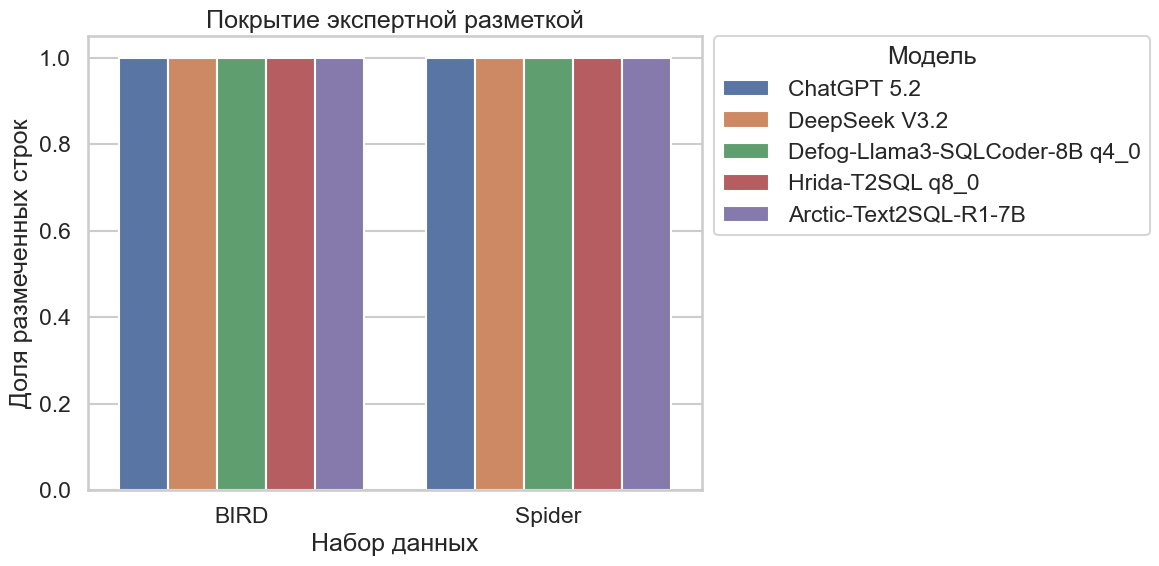

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/expert_coverage_ru.png


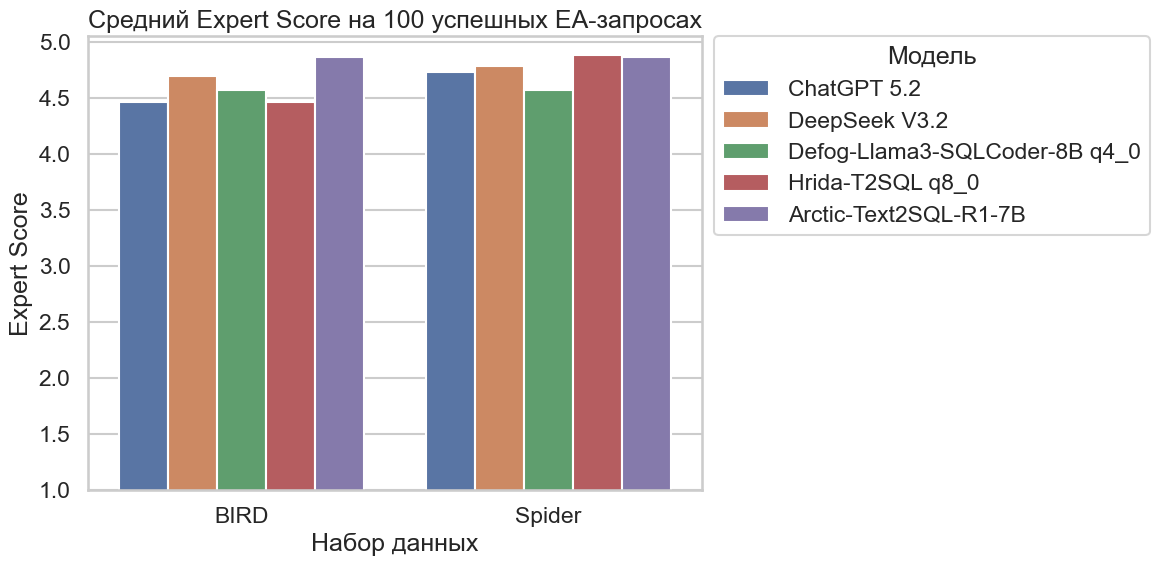

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/ea/expert_score_ru.png


In [8]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

expert_df = pd.read_csv(expert_path) if Path(expert_path).exists() else pd.DataFrame()
metrics_dir = get_results_dir() / 'metrics' / RUN_LABEL
expert_by_model_path = metrics_dir / 'expert_scores_by_model.csv'
expert_agreement_path = metrics_dir / 'expert_interrater_agreement.csv'
expert_by_model_df = pd.read_csv(expert_by_model_path) if expert_by_model_path.exists() else pd.DataFrame()
expert_agreement_df = pd.read_csv(expert_agreement_path) if expert_agreement_path.exists() else pd.DataFrame()

if not expert_df.empty and 'model_display_name' not in expert_df.columns:
    display_map = outcomes_df[['model_name', 'model_display_name']].drop_duplicates()
    expert_df = expert_df.merge(display_map, on='model_name', how='left')
    expert_df['model_display_name'] = expert_df['model_display_name'].fillna(expert_df['model_name'])
if not expert_df.empty:
    expert_df = expert_df[expert_df['model_display_name'].isin(MAIN_REPORT_MODELS)].copy()
    expert_df['model_display_name'] = pd.Categorical(expert_df['model_display_name'], categories=MAIN_REPORT_MODELS, ordered=True)

score_cols = ['completeness', 'efficiency', 'readability']
for col in score_cols:
    if col not in expert_df.columns:
        expert_df[col] = pd.NA
    else:
        expert_df[col] = pd.to_numeric(expert_df[col], errors='coerce')
if 'expert_score' not in expert_df.columns and not expert_df.empty:
    expert_df['expert_score'] = expert_df[score_cols].mean(axis=1)
elif 'expert_score' in expert_df.columns:
    expert_df['expert_score'] = pd.to_numeric(expert_df['expert_score'], errors='coerce')

expert_df['is_scored'] = expert_df[score_cols].notna().all(axis=1) if not expert_df.empty else pd.Series(dtype=bool)
display(expert_df.head())

if not expert_df.empty:
    coverage = (
        expert_df.groupby(['benchmark', 'model_display_name'], observed=False)['is_scored']
        .agg(['sum', 'count'])
        .reset_index()
        .rename(columns={'sum': 'scored_rows', 'count': 'total_rows'})
    )
    coverage['coverage'] = coverage['scored_rows'] / coverage['total_rows'].clip(lower=1)
    coverage['benchmark_ru'] = coverage['benchmark'].map(BENCHMARK_LABELS).fillna(coverage['benchmark'])
    display(coverage.round(3))

    scored_df = expert_df[expert_df['is_scored']].copy()
    if not scored_df.empty:
        expert_summary = (
            scored_df.groupby(['benchmark', 'model_display_name'], observed=False)
            .agg(
                n=('audit_id', 'count') if 'audit_id' in scored_df.columns else ('sample_id', 'count'),
                completeness=('completeness', 'mean'),
                efficiency=('efficiency', 'mean'),
                readability=('readability', 'mean'),
                expert_score=('expert_score', 'mean'),
            )
            .reset_index()
        )
        expert_summary['benchmark_ru'] = expert_summary['benchmark'].map(BENCHMARK_LABELS).fillna(expert_summary['benchmark'])
        display(expert_summary.round(3))

    if not expert_agreement_df.empty:
        display(expert_agreement_df.round(3))

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=coverage, x='benchmark_ru', y='coverage', hue='model_display_name', ax=ax)
    ax.set_title('Покрытие экспертной разметкой')
    ax.set_xlabel('Набор данных')
    ax.set_ylabel('Доля размеченных строк')
    ax.set_ylim(0, 1.05)
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / 'expert_coverage_ru.png'
    _save_current(fig, path)

    if 'expert_summary' in locals() and not expert_summary.empty:
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.barplot(data=expert_summary, x='benchmark_ru', y='expert_score', hue='model_display_name', ax=ax)
        ax.set_title('Средний Expert Score на 100 успешных EA-запросах')
        ax.set_xlabel('Набор данных')
        ax.set_ylabel('Expert Score')
        ax.set_ylim(1, 5.05)
        _legend_outside(ax, 'Модель')
        path = FIGURES_DIR / 'expert_score_ru.png'
        _save_current(fig, path)
else:
    print('Файл экспертной разметки пуст или отсутствует.')


## 8. Выводы

Итоговый блок связывает качество, вычислительные характеристики и наблюдаемые различия между моделями в режиме одного ответа. Выводы из этого ноутбука относятся только к режиму `ea`; результаты `pass_k` интерпретируются отдельно.


In [9]:
from shared.config import load_domain_models

MAIN_REPORT_MODELS = [
    'ChatGPT 5.2',
    'DeepSeek V3.2',
    'Defog-Llama3-SQLCoder-8B q4_0',
    'Hrida-T2SQL q8_0',
    'Arctic-Text2SQL-R1-7B',
]

final_pass_col = pass_metric_cols[-1] if pass_metric_cols else None
conclusion_cols = ['model_display_name', 'benchmark', 'execution_accuracy', 'Tinf', 'Tok', 'Cost']
if final_pass_col is not None:
    conclusion_cols.insert(3, final_pass_col)
conclusions = summary_df[summary_df['model_display_name'].isin(MAIN_REPORT_MODELS)][conclusion_cols].copy()
conclusions = conclusions.sort_values(['benchmark', 'execution_accuracy'], ascending=[True, False])
conclusions_display = conclusions.rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'execution_accuracy': 'Execution Accuracy',
    'Tinf': 'Время инференса, мс',
    'Tok': 'Токены',
    'Cost': 'Стоимость, $',
})
display(conclusions_display.round(4))

model_catalog = load_domain_models('supports_sql')
family_by_display_name = {
    (cfg.get('display_name') or cfg.get('name')): ('M1' if key.startswith('m1_') else 'M2')
    for key, cfg in model_catalog.items()
}
summary_with_family = summary_df[summary_df['model_display_name'].isin(MAIN_REPORT_MODELS)].copy()
summary_with_family['family'] = summary_with_family['model_display_name'].map(family_by_display_name)

if not summary_with_family.empty and summary_with_family['family'].notna().any():
    best_m1 = summary_with_family.loc[
        summary_with_family['family'] == 'M1', 'execution_accuracy'
    ].max()
    best_m2 = summary_with_family.loc[
        summary_with_family['family'] == 'M2', 'execution_accuracy'
    ].max()
    best_m1_name = first_non_null(
        summary_with_family.loc[
            (summary_with_family['family'] == 'M1') & (summary_with_family['execution_accuracy'] == best_m1),
            'model_display_name',
        ]
    )
    best_m2_name = first_non_null(
        summary_with_family.loc[
            (summary_with_family['family'] == 'M2') & (summary_with_family['execution_accuracy'] == best_m2),
            'model_display_name',
        ]
    )

    print()
    print(f'Лучшая EA класса M1: {best_m1:.1%} ({best_m1_name})')
    print(f'Лучшая EA класса M2: {best_m2:.1%} ({best_m2_name})')
    if best_m1 >= best_m2:
        gap = best_m1 - best_m2
        print(f'Разрыв M1 - M2: {gap:.1%}')
        print()
        print('Модели M2 выполняются локально; для M1 учитывается API-стоимость.')
        print(f'Лучшая M2 достигает {best_m2 / best_m1:.0%} качества лучшей M1 по EA.')
    else:
        lead = best_m2 - best_m1
        print(f'Преимущество M2 над лучшей M1: {lead:.1%}')
        print()
        print('Модели M2 выполняются локально; для M1 учитывается API-стоимость.')
        print(f'Лучшая M2 достигает {best_m2 / best_m1:.0%} качества лучшей M1 по EA.')
else:
    print('Нет метрик EA для итоговых выводов.')


,Модель,Бенчмарк,Execution Accuracy,pass@5,"Время инференса, мс",Токены,"Стоимость, $"
0,Arctic-Text2SQL-R1-7B,bird,0.5385,0.5385,6038.1180,1335.3716,0.0000
2,ChatGPT 5.2,bird,0.3657,0.3657,2374.4675,1021.2171,0.0019
6,DeepSeek V3.2,bird,0.3227,0.3227,3494.5106,1051.5183,0.0003
8,Defog-Llama3-SQLCoder-8B q4_0,bird,0.2634,0.2634,733.3158,974.1232,0.0000
10,Hrida-T2SQL q8_0,bird,0.1551,0.1551,1081.1594,1440.4817,0.0000
1,Arctic-Text2SQL-R1-7B,spider,0.7718,0.7718,4854.2380,734.6422,0.0000
3,ChatGPT 5.2,spider,0.7427,0.7427,1895.3430,479.2563,0.0009
7,DeepSeek V3.2,spider,0.7369,0.7369,2965.6751,514.9168,0.0002
9,Defog-Llama3-SQLCoder-8B q4_0,spider,0.5629,0.5629,531.0612,426.9159,0.0000
11,Hrida-T2SQL q8_0,spider,0.4913,0.4913,485.6148,668.4507,0.0000



Лучшая EA класса M1: 74.3% (ChatGPT 5.2)
Лучшая EA класса M2: 77.2% (Arctic-Text2SQL-R1-7B)
Преимущество M2 над лучшей M1: 2.9%

Модели M2 выполняются локально; для M1 учитывается API-стоимость.
Лучшая M2 достигает 104% качества лучшей M1 по EA.
